In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import CMR_IA as cmr

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVEDATA = False

In [2]:
# Define word frequency bins
word_freq = [21, 51, 90, 141, 196, 285, 415, 632, 1163, 4332]

In [3]:
# Load Lohnas HR data
df_hr = pd.read_csv("data/simu4_Lohnas_HR.csv", header=None)
df_hr

,0,1,2,3
0,19.116441,0.902874,0,mean
1,19.116441,0.908908,0,sd+
2,19.116441,0.897126,0,sd-
3,56.451442,0.885026,1,mean
4,56.451442,0.892409,1,sd+
5,56.451442,0.878041,1,sd-
6,106.502307,0.887620,2,mean
7,106.502307,0.894405,2,sd+
8,106.502307,0.880635,2,sd-
9,169.730508,0.880436,3,mean


In [4]:
# Pivot HR table
df_hr = df_hr.pivot_table(index=2, columns=3, values=1).reset_index(drop=True)
df_hr

3,mean,sd+,sd-
0,0.902874,0.908908,0.897126
1,0.885026,0.892409,0.878041
2,0.887620,0.894405,0.880635
3,0.880436,0.889216,0.872055
4,0.878640,0.887021,0.870658
5,0.879638,0.890613,0.868862
6,0.869660,0.879039,0.860081
7,0.861877,0.872254,0.851600
8,0.841723,0.853097,0.830747
9,0.836933,0.847510,0.826257


In [5]:
# Add SD and mean columns
df_hr["SD1"] = df_hr[" sd+"] - df_hr[" mean"]
df_hr["SD2"] = df_hr[" mean"] - df_hr[" sd-"]
df_hr["SD"] = df_hr[["SD1", "SD2"]].mean(axis=1)
df_hr["X"] = word_freq
df_hr["Y"] = df_hr[" mean"]
df_hr

3,mean,sd+,sd-,SD1,SD2,SD,X,Y
0,0.902874,0.908908,0.897126,0.006034,0.005747,0.005891,21,0.902874
1,0.885026,0.892409,0.878041,0.007383,0.006984,0.007184,51,0.885026
2,0.887620,0.894405,0.880635,0.006785,0.006984,0.006885,90,0.887620
3,0.880436,0.889216,0.872055,0.008780,0.008381,0.008581,141,0.880436
4,0.878640,0.887021,0.870658,0.008381,0.007982,0.008182,196,0.878640
5,0.879638,0.890613,0.868862,0.010975,0.010776,0.010876,285,0.879638
6,0.869660,0.879039,0.860081,0.009379,0.009579,0.009479,415,0.869660
7,0.861877,0.872254,0.851600,0.010377,0.010277,0.010327,632,0.861877
8,0.841723,0.853097,0.830747,0.011375,0.010975,0.011175,1163,0.841723
9,0.836933,0.847510,0.826257,0.010576,0.010676,0.010626,4332,0.836933


In [6]:
# Load Lohnas FAR data
df_far = pd.read_csv("data/simu4_Lohnas_FAR.csv", header=None)
df_far

,0,1,2,3
0,18.913086,0.113686,0,mean
1,18.913086,0.120480,0,sd+
2,18.913086,0.106693,0,sd-
3,51.513779,0.131868,1,mean
4,51.513779,0.138961,1,sd+
5,51.513779,0.124675,1,sd-
6,91.743679,0.142657,2,mean
7,91.743679,0.148751,2,sd+
8,91.743679,0.136364,2,sd-
9,140.872125,0.163736,3,mean


In [7]:
# Pivot FAR table
df_far = df_far.pivot_table(index=2, columns=3, values=1).reset_index(drop=True)
df_far

3,mean,sd+,sd-
0,0.113686,0.120480,0.106693
1,0.131868,0.138961,0.124675
2,0.142657,0.148751,0.136364
3,0.163736,0.169331,0.157842
4,0.171429,0.177822,0.164635
5,0.183017,0.190709,0.175025
6,0.186613,0.194705,0.179021
7,0.193207,0.201598,0.185315
8,0.191508,0.199600,0.183417
9,0.192807,0.203497,0.182418


In [8]:
# Add SD and mean columns to FAR
df_far["SD1"] = df_far[" sd+"] - df_far[" mean"]
df_far["SD2"] = df_far[" mean"] - df_far[" sd-"]
df_far["SD"] = df_far[["SD1", "SD2"]].mean(axis=1)
df_far["X"] = word_freq
df_far["Y"] = df_far[" mean"]
df_far

3,mean,sd+,sd-,SD1,SD2,SD,X,Y
0,0.113686,0.120480,0.106693,0.006793,0.006993,0.006893,21,0.113686
1,0.131868,0.138961,0.124675,0.007093,0.007193,0.007143,51,0.131868
2,0.142657,0.148751,0.136364,0.006094,0.006294,0.006194,90,0.142657
3,0.163736,0.169331,0.157842,0.005594,0.005894,0.005744,141,0.163736
4,0.171429,0.177822,0.164635,0.006394,0.006793,0.006593,196,0.171429
5,0.183017,0.190709,0.175025,0.007692,0.007992,0.007842,285,0.183017
6,0.186613,0.194705,0.179021,0.008092,0.007592,0.007842,415,0.186613
7,0.193207,0.201598,0.185315,0.008392,0.007892,0.008142,632,0.193207
8,0.191508,0.199600,0.183417,0.008092,0.008092,0.008092,1163,0.191508
9,0.192807,0.203497,0.182418,0.010689,0.010390,0.010539,4332,0.192807


In [9]:
# Save gt
if SAVEDATA:
    with open("data/simu4_gt.json", "w") as f:
        json.dump(
            {
                "hr": df_hr["Y"].to_numpy().tolist(),
                "hr_std": df_hr["SD"].to_numpy().tolist(),
                "far": df_far["Y"].to_numpy().tolist(),
                "far_std": df_far["SD"].to_numpy().tolist(),
                "word_freq": np.array(word_freq).tolist(),
            },
            f,
            indent=4,
        )

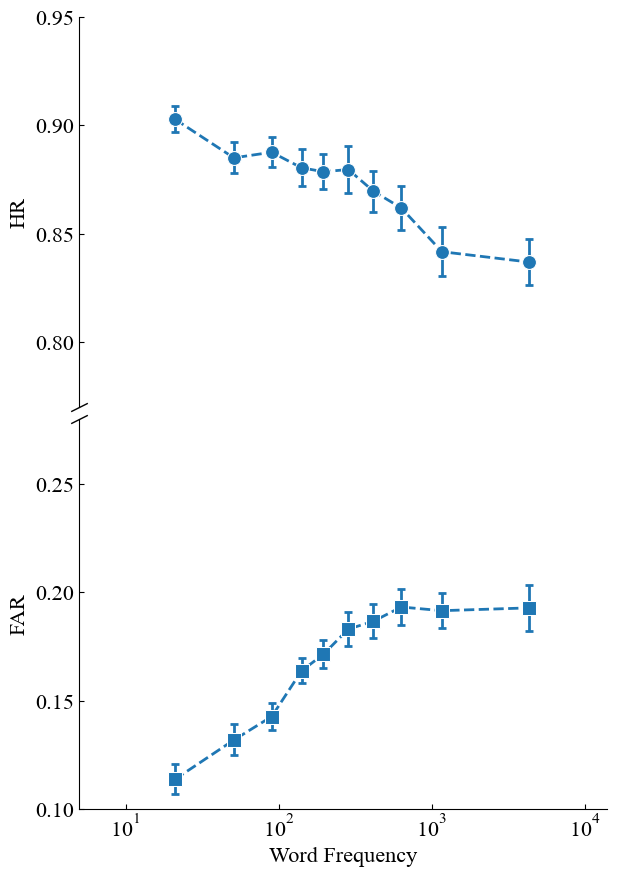

In [10]:
# Plot HR and FAR by word frequency
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 9))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
fig.subplots_adjust(hspace=0.03)

ax1.errorbar(x=df_hr["X"], y=df_hr["Y"], yerr=df_hr["SD"], linewidth=2, marker=None, capsize=3, capthick=2, linestyle="none")
ax2.errorbar(x=df_far["X"], y=df_far["Y"], yerr=df_far["SD"], linewidth=2, marker=None, capsize=3, capthick=2, linestyle="none")

sns.lineplot(data=df_hr, y="Y", x="X", ax=ax1, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")
sns.lineplot(data=df_far, y="Y", x="X", ax=ax2, marker="s", color="C0", markersize=10, linewidth=2, linestyle="--")

ax1.set_ylim(0.77, 0.95)
ax1.set_yticks(np.arange(0.80, 0.96, 0.05))
ax2.set_ylim(0.1, 0.28)
ax2.set_yticks(np.arange(0.1, 0.30, 0.05))
ax1.tick_params(axis="y", direction="in")
ax1.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.tick_params(axis="x", direction="in")
plt.xscale("log")
plt.xlim(5, 14000)

ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)
ax2.minorticks_off()

d = 0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax1.set_ylabel("HR")
ax2.set_ylabel("FAR")
ax2.set_xlabel("Word Frequency")

if SAVEFIG:
    ax1.set_ylabel(None)
    ax1.set_xlabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    plt.savefig("figures/simu4_Lohnas.pdf")

In [11]:
# Print rounded HR and FAR values
df_hr["Y"].to_numpy().round(3), df_far["Y"].to_numpy().round(3)

(array([0.903, 0.885, 0.888, 0.88 , 0.879, 0.88 , 0.87 , 0.862, 0.842,
        0.837]),
 array([0.114, 0.132, 0.143, 0.164, 0.171, 0.183, 0.187, 0.193, 0.192,
        0.193]))